In [1]:
import pandas as pd
import matplotlib.pyplot as plt

baseline = pd.read_csv(
    "../../data/baselines/facility_baselines.csv"
)

print("Baseline loaded successfully")
print("Facilities:", len(baseline))
print("Columns:", len(baseline.columns))

Baseline loaded successfully
Facilities: 23558
Columns: 44


In [2]:
facility_type_summary = (
    baseline.groupby("facility_category")
    .agg(
        facilities=("facility_id", "count"),
        total_events=("total_events", "sum"),
        avg_events_per_facility=("total_events", "mean"),
        median_events_per_facility=("total_events", "median")
    )
    .sort_values("avg_events_per_facility", ascending=False)
)

facility_type_summary

,facilities,total_events,avg_events_per_facility,median_events_per_facility
facility_category,,,,
STEEL_PLANT,1,70,70.000000,70.0
CEMENT_PLANT,5,345,69.000000,4.0
REFINERY,13,235,18.076923,5.0
QUARRY,3931,45131,11.480794,3.0
INDUSTRIAL_AREA,7700,62658,8.137403,3.0
MINE,49,354,7.224490,2.0
OIL_GAS,19,124,6.526316,3.0
WASTE_PROCESSING,651,3867,5.940092,2.0
STORAGE_FACILITY,1339,7738,5.778940,2.0


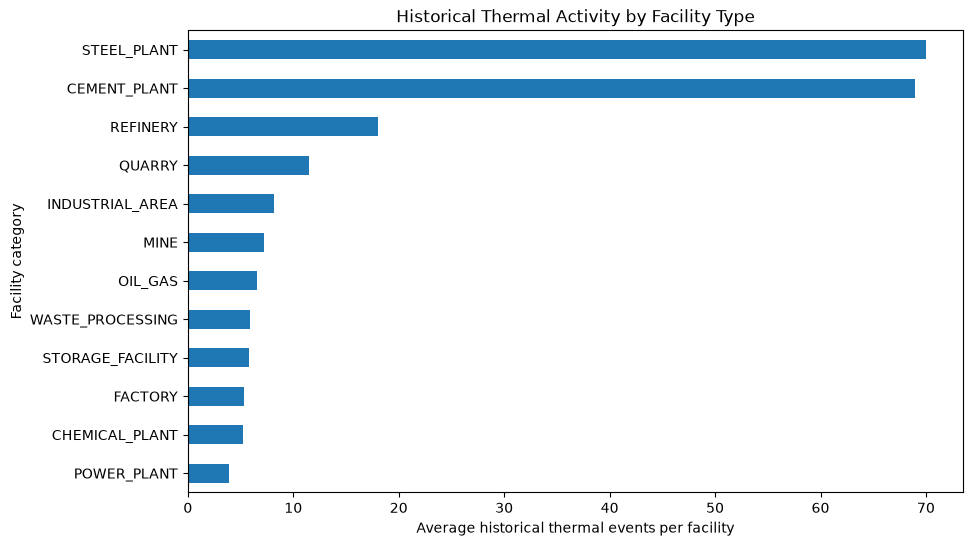

In [3]:
facility_type_summary["avg_events_per_facility"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Average historical thermal events per facility")
plt.ylabel("Facility category")
plt.title("Historical Thermal Activity by Facility Type")

plt.show()


In [4]:
top_facilities = baseline[
    ["facility_id", "facility_name", "facility_category", "total_events"]
].sort_values(
    "total_events", ascending=False
).head(15)

top_facilities

KeyError: "['facility_name'] not in index"

In [5]:
top_facilities = baseline[
    ["facility_id", "facility_category", "total_events"]
].sort_values(
    "total_events", ascending=False
).head(15)

top_facilities

,facility_id,facility_category,total_events
8296,928075506,QUARRY,676
8605,968271870,QUARRY,655
242,117858814,QUARRY,574
236,117807506,QUARRY,557
234,117807504,QUARRY,554
9596,988918471,QUARRY,540
9590,988893557,QUARRY,530
232,117695917,QUARRY,522
79,77362486,QUARRY,514
238,117807509,QUARRY,486


In [6]:
top_facilities = baseline[
    ["facility_id", "facility_category", "total_events"]
].sort_values(
    "total_events", ascending=False
).head(15)

top_facilities

,facility_id,facility_category,total_events
8296,928075506,QUARRY,676
8605,968271870,QUARRY,655
242,117858814,QUARRY,574
236,117807506,QUARRY,557
234,117807504,QUARRY,554
9596,988918471,QUARRY,540
9590,988893557,QUARRY,530
232,117695917,QUARRY,522
79,77362486,QUARRY,514
238,117807509,QUARRY,486


In [7]:
facilities = pd.read_csv(
    "../../data/external/m5_historical/industrial_facilities.csv"
)

top_with_names = top_facilities.merge(
    facilities[["facility_id", "facility_name"]],
    on="facility_id",
    how="left"
)

top_with_names[
    ["facility_id", "facility_name", "facility_category", "total_events"]
]

KeyError: "['facility_name'] not in index"

In [8]:
top_with_names = top_facilities.merge(
    facilities[["facility_id", "name"]],
    on="facility_id",
    how="left"
)

top_with_names[
    ["facility_id", "name", "facility_category", "total_events"]
]

,facility_id,name,facility_category,total_events
0,928075506,Ananta coal mine,QUARRY,676
1,968271870,Basundhara (West) Coal Mine,QUARRY,655
2,117858814,NaN,QUARRY,574
3,117807506,Amalgamated Keshalpur-West Mudidih (AKWMC) Coa...,QUARRY,557
4,117807504,Cluster 8 and Cluster 9 Coal Mines,QUARRY,554
5,988918471,NaN,QUARRY,540
6,988893557,Bhubhaneshwari coal mine,QUARRY,530
7,117695917,Cluster 11 and Cluster 7 (BCCL) Coal Mines,QUARRY,522
8,77362486,Chirimiri Coal Mine,QUARRY,514
9,117807509,NaN,QUARRY,486


In [9]:
intensity_by_type = (
    baseline.groupby("facility_category")
    .agg(
        facilities=("facility_id", "count"),
        avg_frp=("mean_frp_mw", "mean"),
        median_frp=("mean_frp_mw", "median"),
        max_frp=("max_frp_mw", "max")
    )
    .sort_values("avg_frp", ascending=False)
)

intensity_by_type

,facilities,avg_frp,median_frp,max_frp
facility_category,,,,
POWER_PLANT,7673,5.379554,4.539167,561.74
QUARRY,3931,4.973405,4.401667,203.44
MINE,49,4.790466,4.280000,174.66
INDUSTRIAL_AREA,7700,4.581175,4.036667,260.60
FACTORY,2172,4.520062,3.872332,208.99
WASTE_PROCESSING,651,4.450770,4.140000,160.89
STORAGE_FACILITY,1339,4.399461,3.930000,211.60
CHEMICAL_PLANT,5,3.909812,3.479643,18.17
OIL_GAS,19,3.503541,3.490000,14.34


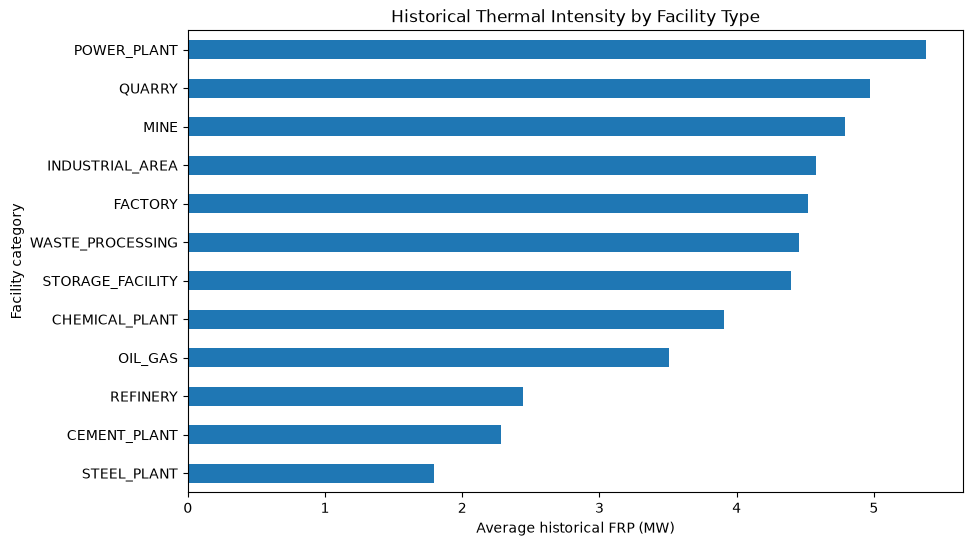

In [10]:
intensity_by_type["avg_frp"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Average historical FRP (MW)")
plt.ylabel("Facility category")
plt.title("Historical Thermal Intensity by Facility Type")
plt.show()

In [11]:
day_night = {
    "Day": baseline["day_events"].sum(),
    "Night": baseline["night_events"].sum()
}

day_night

{'Day': np.int64(104406), 'Night': np.int64(57949)}

In [12]:
weekday_weekend = {
    "Weekday": baseline["weekday_events"].sum(),
    "Weekend": baseline["weekend_events"].sum()
}

weekday_weekend

{'Weekday': np.int64(115268), 'Weekend': np.int64(47087)}

In [13]:
V

NameError: name 'V' is not defined

In [14]:
hourly_activity = (
    baseline.groupby("most_active_hour")
    ["total_events"]
    .sum()
    .sort_values(ascending=False)
)

hourly_activity

most_active_hour
7     62204
8     39087
19    32078
20    24852
6      2765
21      875
9       449
18       39
5         5
22        1
Name: total_events, dtype: int64

In [15]:
thermal_events = pd.read_csv(
    "../../data/external/m5_historical/historical_thermal_events.csv"
)

thermal_events["start_time"] = pd.to_datetime(
    thermal_events["start_time"]
)

hourly_events = (
    thermal_events.groupby("hour")
    .size()
    .sort_values(ascending=False)
)

hourly_events

hour
7     53980
8     43404
20    28572
19    25872
6      5424
21     3075
9      1569
18      428
5        29
22        2
dtype: int64

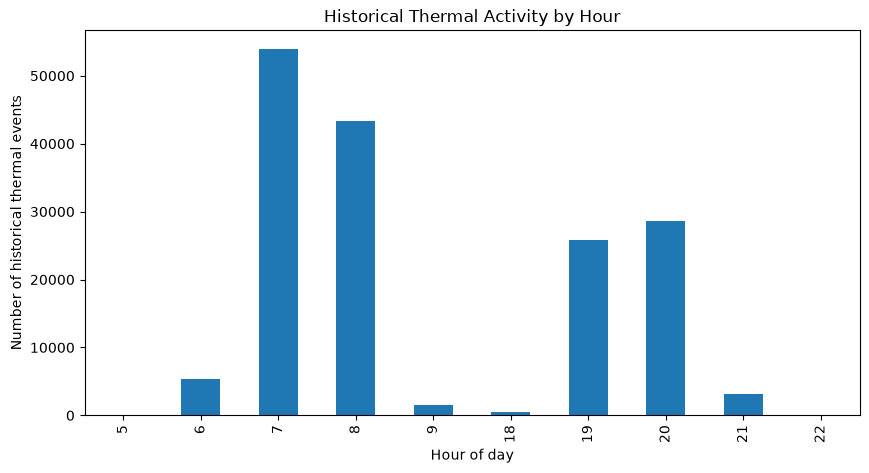

In [16]:
hourly_events.sort_index().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Hour of day")
plt.ylabel("Number of historical thermal events")
plt.title("Historical Thermal Activity by Hour")
plt.show()

In [17]:
monthly_activity = (
    baseline[["facility_id", "active_months"]]
    .sort_values("active_months", ascending=False)
)

monthly_activity.head(15)

,facility_id,active_months
12545,1088882848,13
16832,1466074251,13
51,59837236,13
12209,1068597510,13
9625,989739593,13
7190,876239837,13
6725,842578051,13
15794,1381466372,13
1478,285680302,13
14758,1279668272,13


In [18]:
active_month_distribution = (
    baseline["active_months"]
    .value_counts()
    .sort_index()
)

active_month_distribution

active_months
1     11017
2      5164
3      3154
4      1892
5      1040
6       563
7       270
8       114
9        64
10       76
11       73
12      120
13       11
Name: count, dtype: int64

In [19]:
spatial_by_type = (
    baseline.groupby("facility_category")
    .agg(
        facilities=("facility_id", "count"),
        avg_distance_km=("mean_distance_km", "mean"),
        median_distance_km=("median_distance_km", "median"),
        max_distance_km=("max_distance_km", "mean")
    )
    .sort_values("avg_distance_km")
)

spatial_by_type

,facilities,avg_distance_km,median_distance_km,max_distance_km
facility_category,,,,
STEEL_PLANT,1,0.165356,0.151575,0.328232
REFINERY,13,0.575448,0.289857,0.857282
CEMENT_PLANT,5,0.867431,0.202879,1.176100
CHEMICAL_PLANT,5,1.336079,0.924895,1.998523
MINE,49,1.570892,1.221321,2.231350
POWER_PLANT,7673,1.713850,1.452923,2.240409
WASTE_PROCESSING,651,1.895581,1.830334,2.536869
INDUSTRIAL_AREA,7700,1.997889,1.931137,2.709897
FACTORY,2172,2.015722,1.952328,2.570151


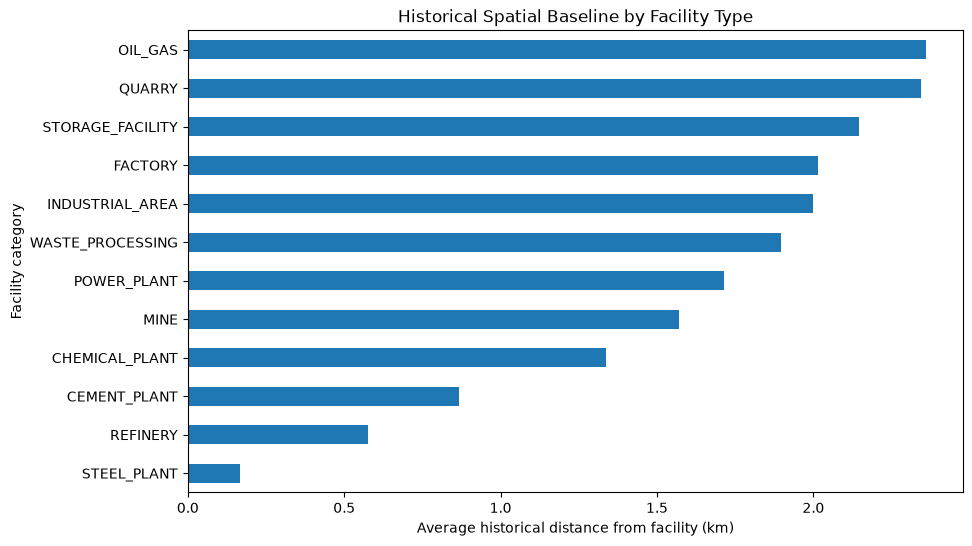

In [20]:
spatial_by_type["avg_distance_km"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Average historical distance from facility (km)")
plt.ylabel("Facility category")
plt.title("Historical Spatial Baseline by Facility Type")
plt.show()